# SQG Trajectory Visualisation

Loads a few trajectories from the data folder and produces:
1. A side-by-side animation of both vertical levels for one trajectory
2. A multi-trajectory comparison animation
3. Frame-to-frame RMSE between consecutive pairs (x_t, x_{t+1})

Output is inline HTML — no ffmpeg required.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from pathlib import Path
from natsort import natsorted

DATA_DIR = Path('../data')
DATA_STD = 2660.0

files = natsorted(DATA_DIR.glob('sqg_N64_1hrly_*.npy'))
print(f'Found {len(files)} trajectory files')

arr = np.load(files[0])
T, C, H, W = arr.shape
print(f'Shape: T={T}, levels={C}, H={H}, W={W}')
print(f'Value range: [{arr.min():.1f}, {arr.max():.1f}]')

Found 100 trajectory files
Shape: T=101, levels=2, H=64, W=64
Value range: [-9346.5, 8743.6]


In [8]:
# ── pick which trajectories and how many timesteps to animate ──────────────
TRAJ_INDICES  = [0, 1, 2]   # which files to load
N_FRAMES      = 50          # timesteps to animate (≤101)
INTERVAL_MS   = 120         # ms between frames
CMAP          = 'RdBu_r'

trajs = []
for idx in TRAJ_INDICES:
    arr = np.load(files[idx]).astype(np.float32) / DATA_STD
    trajs.append(arr[:N_FRAMES])  # (T, 2, H, W)

# shared colour limits (symmetric)
vmax = max(np.abs(t).max() for t in trajs)
print(f'Loaded {len(trajs)} trajectories, vmax={vmax:.3f} (normalised)')

Loaded 3 trajectories, vmax=3.785 (normalised)


## 1. Single-trajectory — both levels side by side

In [9]:
traj = trajs[0]   # (T, 2, H, W)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle('Trajectory 0 — level 0 (left) and level 1 (right)', fontsize=11)

ims = [
    axes[0].imshow(traj[0, 0], cmap=CMAP, vmin=-vmax, vmax=vmax, origin='lower'),
    axes[1].imshow(traj[0, 1], cmap=CMAP, vmin=-vmax, vmax=vmax, origin='lower'),
]
for ax, lv in zip(axes, ['Level 0 (surface)', 'Level 1 (interior)']):
    ax.set_title(lv)
    ax.axis('off')

plt.colorbar(ims[0], ax=axes[0], fraction=0.046)
plt.colorbar(ims[1], ax=axes[1], fraction=0.046)

time_text = fig.text(0.5, 0.02, 't = 0 h', ha='center', fontsize=10)
plt.tight_layout(rect=[0, 0.04, 1, 1])

def update_single(frame):
    ims[0].set_data(traj[frame, 0])
    ims[1].set_data(traj[frame, 1])
    time_text.set_text(f't = {frame} h')
    return ims + [time_text]

ani_single = animation.FuncAnimation(
    fig, update_single, frames=N_FRAMES, interval=INTERVAL_MS, blit=True
)
plt.close()
HTML(ani_single.to_jshtml())

## 2. Multi-trajectory comparison — level 0 only

In [10]:
n = len(trajs)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4))
fig.suptitle('Trajectory comparison — level 0', fontsize=11)

ims_multi = []
for ax, traj, idx in zip(axes, trajs, TRAJ_INDICES):
    im = ax.imshow(traj[0, 0], cmap=CMAP, vmin=-vmax, vmax=vmax, origin='lower')
    ax.set_title(f'Traj {idx}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ims_multi.append(im)

time_text2 = fig.text(0.5, 0.02, 't = 0 h', ha='center', fontsize=10)
plt.tight_layout(rect=[0, 0.04, 1, 1])

def update_multi(frame):
    for im, traj in zip(ims_multi, trajs):
        im.set_data(traj[frame, 0])
    time_text2.set_text(f't = {frame} h')
    return ims_multi + [time_text2]

ani_multi = animation.FuncAnimation(
    fig, update_multi, frames=N_FRAMES, interval=INTERVAL_MS, blit=True
)
plt.close()
HTML(ani_multi.to_jshtml())

## 3. Frame-to-frame RMSE — how different is x_t from x_{t+1}?

Traj 0  |  mean RMSE(x_t, x_{t+1})  lv0=0.2031  lv1=0.2048
Traj 1  |  mean RMSE(x_t, x_{t+1})  lv0=0.2071  lv1=0.2055
Traj 2  |  mean RMSE(x_t, x_{t+1})  lv0=0.1771  lv1=0.1529


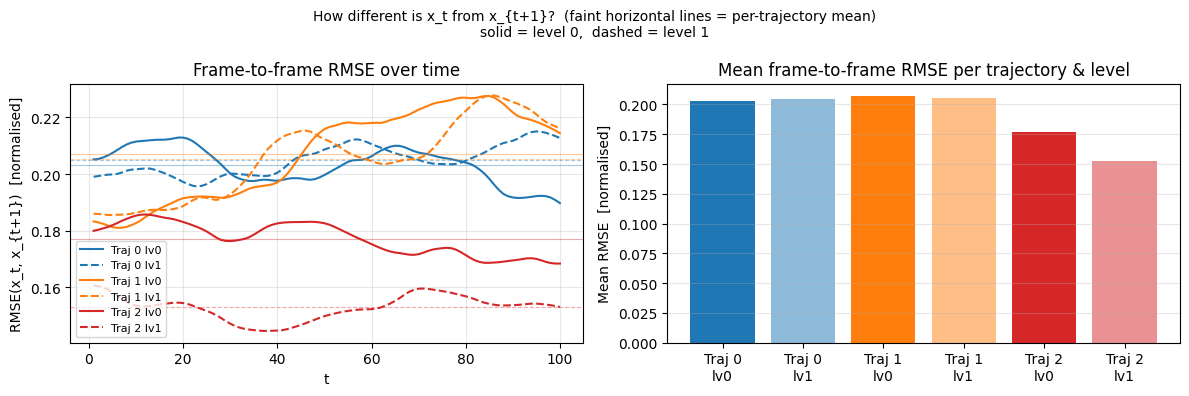

In [12]:
full_trajs = [
    np.load(files[idx]).astype(np.float32) / DATA_STD
    for idx in TRAJ_INDICES
]

colors = plt.cm.tab10(np.linspace(0, 0.3, len(TRAJ_INDICES)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for arr, idx, color in zip(full_trajs, TRAJ_INDICES, colors):
    diff = arr[1:] - arr[:-1]                                       # (T-1, 2, H, W)
    rmse_lv0 = np.sqrt((diff[:, 0] ** 2).mean(axis=(1, 2)))        # (T-1,)
    rmse_lv1 = np.sqrt((diff[:, 1] ** 2).mean(axis=(1, 2)))
    t_axis = np.arange(1, arr.shape[0])

    axes[0].plot(t_axis, rmse_lv0, color=color, label=f'Traj {idx} lv0')
    axes[0].plot(t_axis, rmse_lv1, color=color, linestyle='--', label=f'Traj {idx} lv1')

    mean_lv0, mean_lv1 = rmse_lv0.mean(), rmse_lv1.mean()
    axes[0].axhline(mean_lv0, color=color, linewidth=0.8, alpha=0.4)
    axes[0].axhline(mean_lv1, color=color, linewidth=0.8, alpha=0.4, linestyle='--')

    axes[1].bar([f'Traj {idx}\nlv0'], [mean_lv0], color=color, alpha=1.0)
    axes[1].bar([f'Traj {idx}\nlv1'], [mean_lv1], color=color, alpha=0.5)
    print(f'Traj {idx}  |  mean RMSE(x_t, x_{{t+1}})  lv0={mean_lv0:.4f}  lv1={mean_lv1:.4f}')

axes[0].set_title('Frame-to-frame RMSE over time')
axes[0].set_xlabel('t')
axes[0].set_ylabel('RMSE(x_t, x_{t+1})  [normalised]')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Mean frame-to-frame RMSE per trajectory & level')
axes[1].set_ylabel('Mean RMSE  [normalised]')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(
    'How different is x_t from x_{t+1}?  (faint horizontal lines = per-trajectory mean)\n'
    'solid = level 0,  dashed = level 1',
    fontsize=10
)
plt.tight_layout()
plt.show()

## 4. Save animation to MP4 (optional — requires ffmpeg)

In [ ]:
import shutil

if shutil.which('ffmpeg'):
    out_path = Path('sqg_trajectory0.mp4')
    writer = animation.FFMpegWriter(fps=10, bitrate=1800)
    ani_single.save(out_path, writer=writer)
    print(f'Saved to {out_path.resolve()}')
else:
    print('ffmpeg not found — skipping MP4 export. Install with: sudo apt install ffmpeg')